# Задача 2: Теория возмущений для осциллятора с переменной частотой

**Условие:**
Частота колебаний изменяется от времени как:
$$ \omega^2 = \omega_0^2 (1 + \alpha e^{\lambda t}) $$
Колебания частицы описываются уравнением:
$$ \ddot{x} + \omega_0^2 (1 + \alpha e^{\lambda t}) x = 0 $$

В первом порядке теории возмущений ($|\alpha| \ll 1$) вычислите изменение адиабатического инварианта для невозмущенных колебаний (при $\alpha=0$).

**Аналитическое решение:**

Рассмотрим величину, являющуюся интегралом движения для невозмущенной системы ($\alpha=0$):
$$ I_0 = \frac{\dot{x}^2 + \omega_0^2 x^2}{2\omega_0} $$

Найдем скорость изменения этой величины в возмущенной системе. Продифференцируем $I_0$ по времени:
$$ \frac{dI_0}{dt} = \frac{1}{2\omega_0} (2\dot{x}\ddot{x} + 2\omega_0^2 x \dot{x}) = \frac{\dot{x}}{\omega_0} (\ddot{x} + \omega_0^2 x) $$

Из уравнения движения выразим $\ddot{x} + \omega_0^2 x$:
$$ \ddot{x} + \omega_0^2 x = -\omega_0^2 \alpha e^{\lambda t} x $$

Подставим это в выражение для производной:
$$ \frac{dI_0}{dt} = \frac{\dot{x}}{\omega_0} (-\omega_0^2 \alpha e^{\lambda t} x) = -\alpha \omega_0 e^{\lambda t} x \dot{x} $$

В первом порядке теории возмущений мы можем подставить в правую часть решение невозмущенного уравнения:
$$ x_0(t) = A \cos(\omega_0 t + \phi) $$
$$ \dot{x}_0(t) = -A \omega_0 \sin(\omega_0 t + \phi) $$

Тогда произведение $x \dot{x}$:
$$ x \dot{x} \approx x_0 \dot{x}_0 = -A^2 \omega_0 \cos(\omega_0 t + \phi) \sin(\omega_0 t + \phi) = -\frac{1}{2} A^2 \omega_0 \sin(2(\omega_0 t + \phi)) $$

Заметим, что для невозмущенного движения $I_0 = \frac{1}{2} \omega_0 A^2$, откуда $A^2 = \frac{2I_0}{\omega_0}$.
Следовательно:
$$ x \dot{x} \approx -I_0 \sin(2\omega_0 t + 2\phi) $$

Подставляем обратно в уравнение для $dI_0/dt$:
$$ \frac{dI_0}{dt} \approx -\alpha \omega_0 e^{\lambda t} (-I_0 \sin(2\omega_0 t + 2\phi)) = \alpha \omega_0 I_0 e^{\lambda t} \sin(2\omega_0 t + 2\phi) $$

Интегрируем по времени от $0$ до $t$ (считая $I_0$ в правой части постоянным в первом приближении):
$$ \Delta I_0(t) = \int_0^t \alpha \omega_0 I_0 e^{\lambda \tau} \sin(2\omega_0 \tau + 2\phi) d\tau $$

Используем табличный интеграл $\int e^{ax} \sin(bx+c) dx = \frac{e^{ax}}{a^2+b^2} (a \sin(bx+c) - b \cos(bx+c))$:
Здесь $a=\lambda$, $b=2\omega_0$, $c=2\phi$.

$$ \Delta I_0(t) = \alpha \omega_0 I_0 \left[ \frac{e^{\lambda \tau}}{\lambda^2 + 4\omega_0^2} (\lambda \sin(2\omega_0 \tau + 2\phi) - 2\omega_0 \cos(2\omega_0 \tau + 2\phi)) \right]_0^t $$

Это и есть искомое изменение адиабатического инварианта в первом порядке.

<>:62: SyntaxWarning: invalid escape sequence '\D'
<>:66: SyntaxWarning: invalid escape sequence '\D'
<>:62: SyntaxWarning: invalid escape sequence '\D'
<>:66: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_28759/509096434.py:62: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(t, Delta_I_numeric, label='Численное решение $\Delta I_0(t)$', linewidth=2)
/tmp/ipykernel_28759/509096434.py:66: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('$\Delta I_0$')


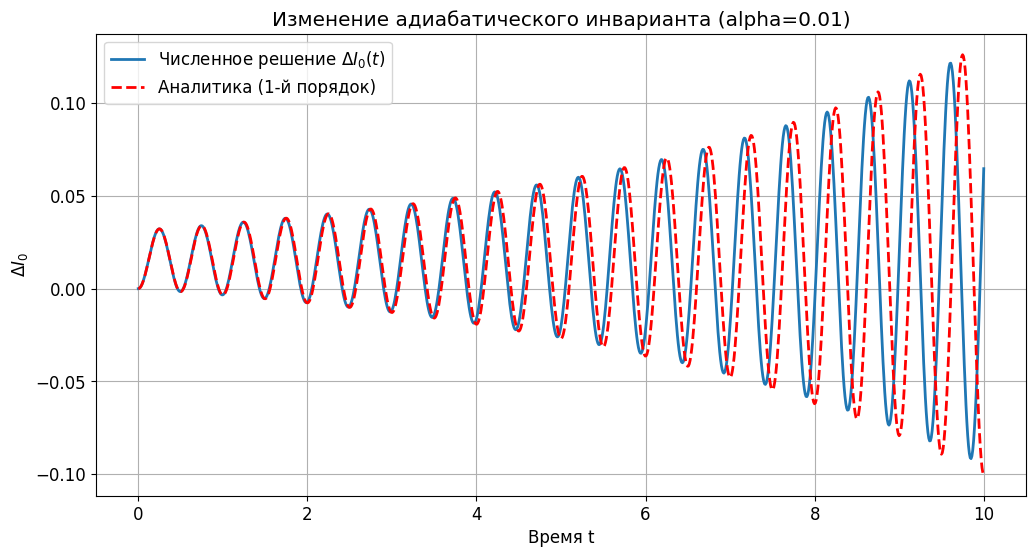

Максимальная ошибка: 1.766290e-01
Относительная ошибка к концу: 2.5519


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Настройка графиков
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

def system_dynamics(t, y, omega0, alpha, lam):
    """
    Система дифференциальных уравнений:
    dx/dt = v
    dv/dt = -omega0^2 * (1 + alpha * exp(lam * t)) * x
    """
    x, v = y
    dxdt = v
    dvdt = -omega0**2 * (1 + alpha * np.exp(lam * t)) * x
    return [dxdt, dvdt]

# Параметры
omega0 = 2 * np.pi * 1.0
alpha = 0.01  # Малое возмущение
lam = 0.2     # Скорость роста возмущения
t_max = 10.0
t_eval = np.linspace(0, t_max, 1000)

# Начальные условия
x0 = 1.0
v0 = 0.0
initial_state = [x0, v0]

# Численное решение
sol = solve_ivp(system_dynamics, [0, t_max], initial_state, t_eval=t_eval, args=(omega0, alpha, lam), rtol=1e-9, atol=1e-9)
x = sol.y[0]
v = sol.y[1]
t = sol.t

# Вычисление инварианта I0 (для невозмущенной системы)
I0_numeric = (v**2 + omega0**2 * x**2) / (2 * omega0)
I0_initial = I0_numeric[0]
Delta_I_numeric = I0_numeric - I0_initial

# Аналитическое предсказание изменения
# Начальная фаза phi. x0 = A cos(phi), v0 = -A w0 sin(phi).
# Если v0=0, то phi=0 (или pi), A=x0.
phi = 0
A = x0

def analytical_delta_I(t, omega0, alpha, lam, I0, phi):
    denom = lam**2 + 4*omega0**2
    
    term_t = np.exp(lam * t) * (lam * np.sin(2*omega0*t + 2*phi) - 2*omega0 * np.cos(2*omega0*t + 2*phi))
    term_0 = (lam * np.sin(2*phi) - 2*omega0 * np.cos(2*phi))
    
    return alpha * omega0 * I0 / denom * (term_t - term_0)

Delta_I_analytic = analytical_delta_I(t, omega0, alpha, lam, I0_initial, phi)

# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(t, Delta_I_numeric, label='Численное решение $\Delta I_0(t)$', linewidth=2)
plt.plot(t, Delta_I_analytic, 'r--', label='Аналитика (1-й порядок)', linewidth=2)
plt.title(f'Изменение адиабатического инварианта (alpha={alpha})')
plt.xlabel('Время t')
plt.ylabel('$\Delta I_0$')
plt.legend()
plt.grid(True)
plt.show()

# Проверка ошибки
error = np.abs(Delta_I_numeric - Delta_I_analytic)
print(f"Максимальная ошибка: {np.max(error):.6e}")
print(f"Относительная ошибка к концу: {error[-1]/np.abs(Delta_I_numeric[-1]):.4f}")